# 09 · Pseudo-Label V4 + Segmentation V4 — Leaf Mask + Bilateral Filter

## Vấn đề của V2/V3/V4.0

- **V2**: Không loại được background (trời/đất). GradCAM kích hoạt trên cả background → noise.
- **V3 (SAM)**: SAM expand mask +70% coverage — segment toàn bộ lá thay vì chỉ đốm bệnh.
- **V4.0 (GrabCut)**: GrabCut fail silent trên 25–40% disease images → 775 empty masks → model học signal mâu thuẫn → IoU 0.44 (tệ hơn cả V2).

## Hướng V4.1: Bilateral Filter (không dependency ngoài OpenCV)

| Bước | Mô tả | Tại sao tốt hơn |
|------|-------|----------------|
| **Leaf mask** | HSV green+yellow range, fallback nếu lá đổi màu | Loại trời/đất/cành; không bỏ sót lá LEAF_BLIGHT vàng |
| **Bilateral filter** | Edge-preserving smooth trên heatmap | Activation "chảy" theo vùng cùng màu bệnh, dừng tại biên màu; không bao giờ trả empty |
| **Percentile threshold** | Tính trên leaf pixels only | Coverage target chính xác hơn V2 (không bị bias bởi background zeros) |
| **Morphological + top-K CC** | Ellipse 5×5 + top-3 ≥ 400px | Giống V2 |
| **Hard fallback** | Nếu vẫn empty → raw percentile threshold | Đảm bảo 0 empty masks |

## So sánh

| | V2 | V3 (SAM) | V4.0 (GrabCut) | **V4.1 (Bilateral)** |
|--|--|--|--|--|
| Background removal | ✗ | ✗ | ✅ (nhưng fail silently) | ✅ robust |
| Empty masks | 0 (disease) | 0 | 775 (!) | 0 |
| Coverage variance | Low (std 0.08) | High (std 0.20) | Very high (std 0.21) | Low (target) |
| External deps | ✗ | SAM 360MB | ✗ | ✗ |

**Output:** Labels → `data/pseudo_labels_v4_train/` · Model → `models/segmentation_v4/`

In [ ]:
import subprocess, sys

def ensure_pkg(pip_name, import_name=None):
    import_name = import_name or pip_name.replace('-', '_')
    try:
        __import__(import_name)
        print(f'[OK] {pip_name}')
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
        print(f'[Installed] {pip_name}')

ensure_pkg('segmentation-models-pytorch', 'segmentation_models_pytorch')
ensure_pkg('albumentations')

# Dense CRF — prebuilt wheels available for Python 3.10+ on Windows
# Falls back to GrabCut if install fails
try:
    ensure_pkg('pydensecrf', 'pydensecrf')
    import pydensecrf.densecrf as _dcrf_test
    print('[OK] pydensecrf — Dense CRF enabled')
except Exception as e:
    print(f'[WARN] pydensecrf not available ({e}). GrabCut fallback will be used.')

In [ ]:
import os, sys, json, random
proj_root = r'e:\Master\thesis-clean'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from utils.models import EfficientNetClassifier

# Dense CRF availability check
try:
    import pydensecrf.densecrf as dcrf_module
    from pydensecrf.utils import unary_from_softmax
    DCRF_AVAILABLE = True
except ImportError:
    DCRF_AVAILABLE = False

plt.style.use('default')
sns.set_palette('husl')

CLASS_NAMES  = ['ALGAL_LEAF_SPOT','ALLOCARIDARA_ATTACK','HEALTHY_LEAF','LEAF_BLIGHT','PHOMOPSIS_LEAF_SPOT']
CLASS_LABELS = ['Algal Leaf Spot','Allocaridara Attack','Healthy Leaf','Leaf Blight','Phomopsis Leaf Spot']
CLASS_COLORS = ['#E69F00','#56B4E9','#009E73','#0072B2','#D55E00']
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: l for i, l in enumerate(CLASS_LABELS)}

VIZ_DIR_LABEL = os.path.join(proj_root, 'visualizations', 'pseudo_labeling_v4')
VIZ_DIR_SEG   = os.path.join(proj_root, 'visualizations', 'segmentation_v4')
os.makedirs(VIZ_DIR_LABEL, exist_ok=True)
os.makedirs(VIZ_DIR_SEG,   exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device       : {device}')
print(f'proj_root    : {proj_root}')
print(f'Dense CRF    : {"enabled" if DCRF_AVAILABLE else "disabled — GrabCut fallback"}')

device       : cuda
proj_root    : e:\Master\thesis-clean
Dense CRF    : disabled — GrabCut fallback


---
## PHẦN 1 — Pseudo-Label Generation V4

In [ ]:
train_dir = os.path.join(proj_root, 'notebooks', 'data', 'raw', 'train')
selected_samples = []
for cls_name in CLASS_NAMES:
    cls_dir = Path(train_dir) / cls_name
    cls_idx = CLASS_TO_IDX[cls_name]
    imgs = sorted(list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')))
    for img_path in imgs:
        selected_samples.append((str(img_path), cls_idx, cls_name))
    print(f'  {cls_name}: {len(imgs)} ảnh')
print(f'\nTổng: {len(selected_samples)} ảnh')

  ALGAL_LEAF_SPOT: 513 ảnh
  ALLOCARIDARA_ATTACK: 639 ảnh
  HEALTHY_LEAF: 683 ảnh
  LEAF_BLIGHT: 655 ảnh
  PHOMOPSIS_LEAF_SPOT: 614 ảnh

Tổng: 3104 ảnh


In [ ]:
model_cls = EfficientNetClassifier(num_classes=len(CLASS_NAMES), backbone='efficientnet_b0', pretrained=False)
ckpt_path = os.path.join(proj_root, 'notebooks', 'models', 'classification', 'checkpoints', 'best_model.pth')
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model_cls.load_state_dict(checkpoint['model_state_dict'])
model_cls.to(device).eval()
print(f'Classifier loaded: val_acc={checkpoint.get("val_acc", "N/A")}')

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
class MultiScaleGradCAMpp:
    """GradCAM++ trên 2 layer (14×14 + 7×7), fused 0.6:0.4. Giống NB06."""

    def __init__(self, model, layer_fine_name, layer_coarse_name, device, weight_fine=0.6):
        self.model  = model.to(device)
        self.model.eval()
        self.device = device
        self.w_fine   = weight_fine
        self.w_coarse = 1.0 - weight_fine
        self.activations = {}
        self.gradients   = {}
        mods = dict(model.named_modules())
        mods[layer_fine_name].register_forward_hook(self._act_hook('fine'))
        mods[layer_fine_name].register_full_backward_hook(self._grad_hook('fine'))
        mods[layer_coarse_name].register_forward_hook(self._act_hook('coarse'))
        mods[layer_coarse_name].register_full_backward_hook(self._grad_hook('coarse'))

    def _act_hook(self, name):
        def h(m, i, o): self.activations[name] = o.detach().cpu()
        return h

    def _grad_hook(self, name):
        def h(m, gi, go): self.gradients[name] = go[0].detach().cpu()
        return h

    def _cam_single(self, act_t, grad_t, out_size):
        act  = act_t[0].numpy(); grad = grad_t[0].numpy()
        eps  = 1e-7
        g2   = grad**2; g3 = grad**3
        sa   = np.sum(act, axis=(1,2), keepdims=True)
        denom = 2*g2 + sa*g3 + eps
        alpha = g2 / denom
        w     = np.sum(alpha * np.maximum(grad, 0), axis=(1,2))
        cam   = np.maximum(np.sum(w[:,None,None]*act, axis=0), 0)
        cam   = cv2.resize(cam, out_size)
        if cam.max() > cam.min(): cam = (cam-cam.min())/(cam.max()-cam.min())
        return cam

    def generate(self, inp, target_class):
        inp = inp.to(self.device)
        self.activations.clear(); self.gradients.clear()
        self.model.zero_grad()
        out = self.model(inp)
        conf = torch.softmax(out, dim=1)[0, target_class].item()
        pred = out.argmax(dim=1).item()
        out[0, target_class].backward()
        W, H = inp.shape[3], inp.shape[2]
        cf = self._cam_single(self.activations['fine'],   self.gradients['fine'],   (W,H))
        cc = self._cam_single(self.activations['coarse'], self.gradients['coarse'], (W,H))
        fused = self.w_fine*cf + self.w_coarse*cc
        if fused.max() > fused.min(): fused = (fused-fused.min())/(fused.max()-fused.min())
        return fused, conf, pred


def get_last_conv(model, block_idx):
    prefix = f'base.features.{block_idx}'
    return [n for n,m in model.named_modules() if n.startswith(prefix) and isinstance(m, nn.Conv2d)][-1]

layer_fine   = get_last_conv(model_cls, 6)
layer_coarse = get_last_conv(model_cls, 8)
gradcam_v4   = MultiScaleGradCAMpp(model_cls, layer_fine, layer_coarse, device, weight_fine=0.6)
print(f'GradCAM++ ready | fine={layer_fine} | coarse={layer_coarse}')

## V4 Helper Functions — Revised

**V4.1 cải tiến so với V4.0 (GrabCut):**

- **Bỏ GrabCut** — GrabCut fail silently trên 25–40% disease images (trả về all-BG mà không raise exception), tạo ra 775 empty mask làm training signal mâu thuẫn.
- **Bilateral filter** thay thế: edge-preserving smoothing trực tiếp trên GradCAM heatmap. Pixel cùng màu → smooth together → boundary theo cạnh thực. Không có empty output.
- **Robust leaf mask**: mở rộng HSV range cho lá vàng/nâu bệnh; nếu detected area < 20% → fallback full image (tránh bỏ sót lá LEAF_BLIGHT đổi màu vàng).
- **Hard fallback**: nếu mask sau tất cả pipeline vẫn empty → dùng percentile threshold thô trực tiếp (không bao giờ trả về mask trắng).

Pipeline 5 bước:
1. **Leaf mask (HSV robust)** — tách lá + fallback nếu lá đã đổi màu bệnh
2. **Bilateral filter** — smooth heatmap theo biên màu sắc (σ_space=7, σ_color=38)
3. **Masked + percentile threshold** — chỉ tính percentile trên leaf pixels
4. **Morphological cleanup** — ellipse 5×5 close→open
5. **Top-K CC** + hard fallback nếu empty

In [ ]:
KEEP_PCT = {
    'ALGAL_LEAF_SPOT':      0.18,
    'ALLOCARIDARA_ATTACK':  0.20,
    'HEALTHY_LEAF':         0.00,
    'LEAF_BLIGHT':          0.22,
    'PHOMOPSIS_LEAF_SPOT':  0.18,
}


def filter_top_k(mask, min_area=400, top_k=3):
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    areas = [(stats[i, cv2.CC_STAT_AREA], i) for i in range(1, num)
             if stats[i, cv2.CC_STAT_AREA] >= min_area]
    top = sorted(areas, reverse=True)[:top_k]
    out = np.zeros_like(mask)
    for _, i in top: out[labels == i] = 1
    return out


def segment_leaf_mask_robust(image_bgr):
    """
    Robust leaf mask that handles diseased (yellowed/browned) leaves.
    - Green + yellow-green HSV (Hue 20-90) + pale yellow diseased tissue (Hue 15-30)
    - If detected coverage < 20% → return full image (heavily diseased leaf edge case)
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # Green + yellow-green
    lower = np.array([20, 30, 30])
    upper = np.array([90, 255, 255])
    mask  = cv2.inRange(hsv, lower, upper)

    # Also capture yellowed diseased tissue
    yellow_lower = np.array([15, 40, 60])
    yellow_upper = np.array([30, 200, 220])
    mask = cv2.bitwise_or(mask, cv2.inRange(hsv, yellow_lower, yellow_upper))

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (19, 19))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k_open)

    if mask.mean() / 255.0 < 0.20:
        return np.ones(image_bgr.shape[:2], dtype=np.uint8)

    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if num <= 1:
        return np.ones(image_bgr.shape[:2], dtype=np.uint8)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    result  = (labels == largest).astype(np.uint8)

    if result.mean() < 0.15:
        return np.ones(image_bgr.shape[:2], dtype=np.uint8)

    dk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    return cv2.dilate(result, dk, iterations=1)


# Alias — keeps backward compat if kernel has old reference
segment_leaf_mask = segment_leaf_mask_robust


def smooth_heatmap_bilateral(heatmap_float, image_bgr, sigma_space=7, sigma_color=38):
    """
    Edge-preserving bilateral filter on heatmap.
    sigma_color=38 ≈ 15% of 255 — follows disease color boundaries.
    Never returns empty output (no failure mode unlike GrabCut).
    """
    hm_u8    = (heatmap_float * 255).astype(np.uint8)
    smoothed = cv2.bilateralFilter(hm_u8, d=9, sigmaColor=sigma_color, sigmaSpace=sigma_space)
    result   = smoothed.astype(np.float32) / 255.0
    if result.max() > result.min():
        result = (result - result.min()) / (result.max() - result.min() + 1e-8)
    return result


def create_pseudo_mask_v4(heatmap, image_bgr, cls_name, min_cc_area=400, top_k=3):
    """
    V4.1 pipeline:
    1. Robust leaf mask (HSV green+yellow, size fallback)
    2. Bilateral-filtered heatmap (edge-preserving, no empty output)
    3. Percentile threshold on leaf pixels only
    4. Morphological cleanup (ellipse 5x5 close→open)
    5. Top-K CC filter (≥400px)
    6. Hard fallback: raw percentile if still empty
    """
    keep_pct = KEEP_PCT.get(cls_name, 0.20)
    if keep_pct <= 0:
        return np.zeros(heatmap.shape, dtype=np.uint8)

    leaf_mask = segment_leaf_mask_robust(image_bgr)

    smoothed = smooth_heatmap_bilateral(heatmap, image_bgr)

    masked  = smoothed * leaf_mask.astype(np.float32)
    leaf_px = masked[leaf_mask > 0]
    if len(leaf_px) == 0:
        leaf_px = heatmap.flatten()
    thr  = np.percentile(leaf_px, (1.0 - keep_pct) * 100)
    mask = ((masked >= thr) & (leaf_mask > 0)).astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)

    result = filter_top_k(mask, min_area=min_cc_area, top_k=top_k)

    # Hard fallback — never return empty mask
    if result.sum() == 0:
        thr_fb = np.percentile(heatmap, (1.0 - keep_pct) * 100)
        fb     = (heatmap >= thr_fb).astype(np.uint8)
        result = filter_top_k(fb, min_area=200, top_k=top_k)
        if result.sum() == 0:
            result = fb

    return result


print('V4.1 helpers ready — bilateral filter, robust leaf mask, hard fallback')
print(f'Method: {"Dense CRF" if DCRF_AVAILABLE else "Bilateral Filter (OpenCV)"}')
print(f'Coverage targets: { {k: f"{v:.0%}" for k, v in KEEP_PCT.items()} }')

## Generate Pseudo-Label V4

Chạy toàn bộ 3,104 ảnh. Mỗi ảnh: GradCAM++ → Leaf mask → CRF/GrabCut → CC filter.

Output lưu vào `pseudo_labels_v4_train/` và `processed_v4_train/`.

In [12]:
pseudo_dir_v4    = Path(proj_root) / 'notebooks' / 'data' / 'pseudo_labels_v4_train'
processed_dir_v4 = Path(proj_root) / 'notebooks' / 'data' / 'processed_v4_train'
pseudo_dir_v4.mkdir(parents=True, exist_ok=True)
processed_dir_v4.mkdir(parents=True, exist_ok=True)

stats_v4           = []
viz_by_class_v4    = defaultdict(list)
MAX_VIZ_PER_CLASS  = 10

for img_path, cls_idx, cls_name in tqdm(selected_samples, desc='V4 pseudo-label'):
    try:
        orig_pil = Image.open(img_path).convert('RGB').resize((224, 224))
        orig_arr = np.array(orig_pil)                          # [H,W,3] RGB uint8
        orig_bgr = cv2.cvtColor(orig_arr, cv2.COLOR_RGB2BGR)   # BGR for OpenCV

        inp      = infer_transform(orig_pil).unsqueeze(0)
        heatmap, conf, pred = gradcam_v4.generate(inp, cls_idx)

        mask = create_pseudo_mask_v4(heatmap, orig_bgr, cls_name)

        fname     = Path(img_path).name
        base_name = f'{cls_name}_{fname}'

        cv2.imwrite(str(pseudo_dir_v4 / f'{base_name}_pseudo.png'),
                    (mask * 255).astype(np.uint8))
        orig_pil.save(str(processed_dir_v4 / base_name))

        stats_v4.append({
            'filename':      base_name,
            'original_path': img_path,
            'class_name':    cls_name,
            'class_idx':     cls_idx,
            'pred_class':    pred,
            'confidence':    float(conf),
            'mask_coverage': float(mask.mean()),
        })

        if len(viz_by_class_v4[cls_name]) < MAX_VIZ_PER_CLASS:
            hm_col = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
            hm_rgb = cv2.cvtColor(hm_col, cv2.COLOR_BGR2RGB)
            overlay_cam  = cv2.addWeighted(orig_arr, 0.6, hm_rgb, 0.4, 0)
            mask_rgb     = np.zeros_like(orig_arr)
            mask_rgb[:,:,1] = mask * 255
            overlay_mask = cv2.addWeighted(orig_arr, 0.7, mask_rgb, 0.3, 0)
            leaf_vis     = segment_leaf_mask_robust(orig_bgr)  # fixed: use robust version
            viz_by_class_v4[cls_name].append({
                'orig':         orig_arr,
                'heatmap':      heatmap,
                'overlay_cam':  overlay_cam,
                'mask':         mask,
                'overlay_mask': overlay_mask,
                'leaf_mask':    leaf_vis,
                'conf':         float(conf),
            })

    except Exception as e:
        print(f'  Error {img_path}: {e}')

with open(pseudo_dir_v4 / 'pseudo_label_stats_v4.json', 'w') as f:
    json.dump(stats_v4, f, indent=2)

print(f'\nGenerated: {len(stats_v4)} masks')
print(f'Masks   → {pseudo_dir_v4}')
print(f'Images  → {processed_dir_v4}')

V4 pseudo-label: 100%|██████████| 3104/3104 [06:30<00:00,  7.94it/s]



Generated: 3104 masks
Masks   → e:\Master\thesis-clean\notebooks\data\pseudo_labels_v4_train
Images  → e:\Master\thesis-clean\notebooks\data\processed_v4_train


In [13]:
df_v4 = pd.DataFrame(stats_v4)

# Load V2 stats for comparison
v2_stats_path = Path(proj_root) / 'notebooks' / 'data' / 'pseudo_labels_v2_train' / 'pseudo_label_stats_v2.json'
df_v2 = pd.read_json(v2_stats_path) if v2_stats_path.exists() else None

print('=' * 58)
print(f'{"Metric":<28} {"V2":>12} {"V4":>12}')
print('-' * 58)

def show_row(label, v2_val, v4_val):
    print(f'{label:<28} {str(v2_val):>12} {str(v4_val):>12}')

show_row('Total samples', len(df_v2) if df_v2 is not None else 'N/A', len(df_v4))
if df_v2 is not None:
    show_row('Accuracy',
             f"{(df_v2['pred_class']==df_v2['class_idx']).mean():.2%}",
             f"{(df_v4['pred_class']==df_v4['class_idx']).mean():.2%}")
    show_row('Mean coverage',
             f"{df_v2['mask_coverage'].mean():.4f}",
             f"{df_v4['mask_coverage'].mean():.4f}")
    show_row('Near-empty (<0.05)',
             int((df_v2['mask_coverage']<0.05).sum()),
             int((df_v4['mask_coverage']<0.05).sum()))
    show_row('Over-large (>0.5)',
             int((df_v2['mask_coverage']>0.5).sum()),
             int((df_v4['mask_coverage']>0.5).sum()))
print('=' * 58)

print('\n=== V4 Per-Class Coverage ===')
print(df_v4.groupby('class_name')[['mask_coverage']].agg(['mean','std']).round(4))

Metric                                 V2           V4
----------------------------------------------------------
Total samples                        3104         3104
Accuracy                           99.52%       99.52%
Mean coverage                      0.1504       0.1417
Near-empty (<0.05)                    683          684
Over-large (>0.5)                       0            0

=== V4 Per-Class Coverage ===
                    mask_coverage        
                             mean     std
class_name                               
ALGAL_LEAF_SPOT            0.1589  0.0247
ALLOCARIDARA_ATTACK        0.1871  0.0200
HEALTHY_LEAF               0.0000  0.0000
LEAF_BLIGHT                0.2023  0.0252
PHOMOPSIS_LEAF_SPOT        0.1732  0.0120


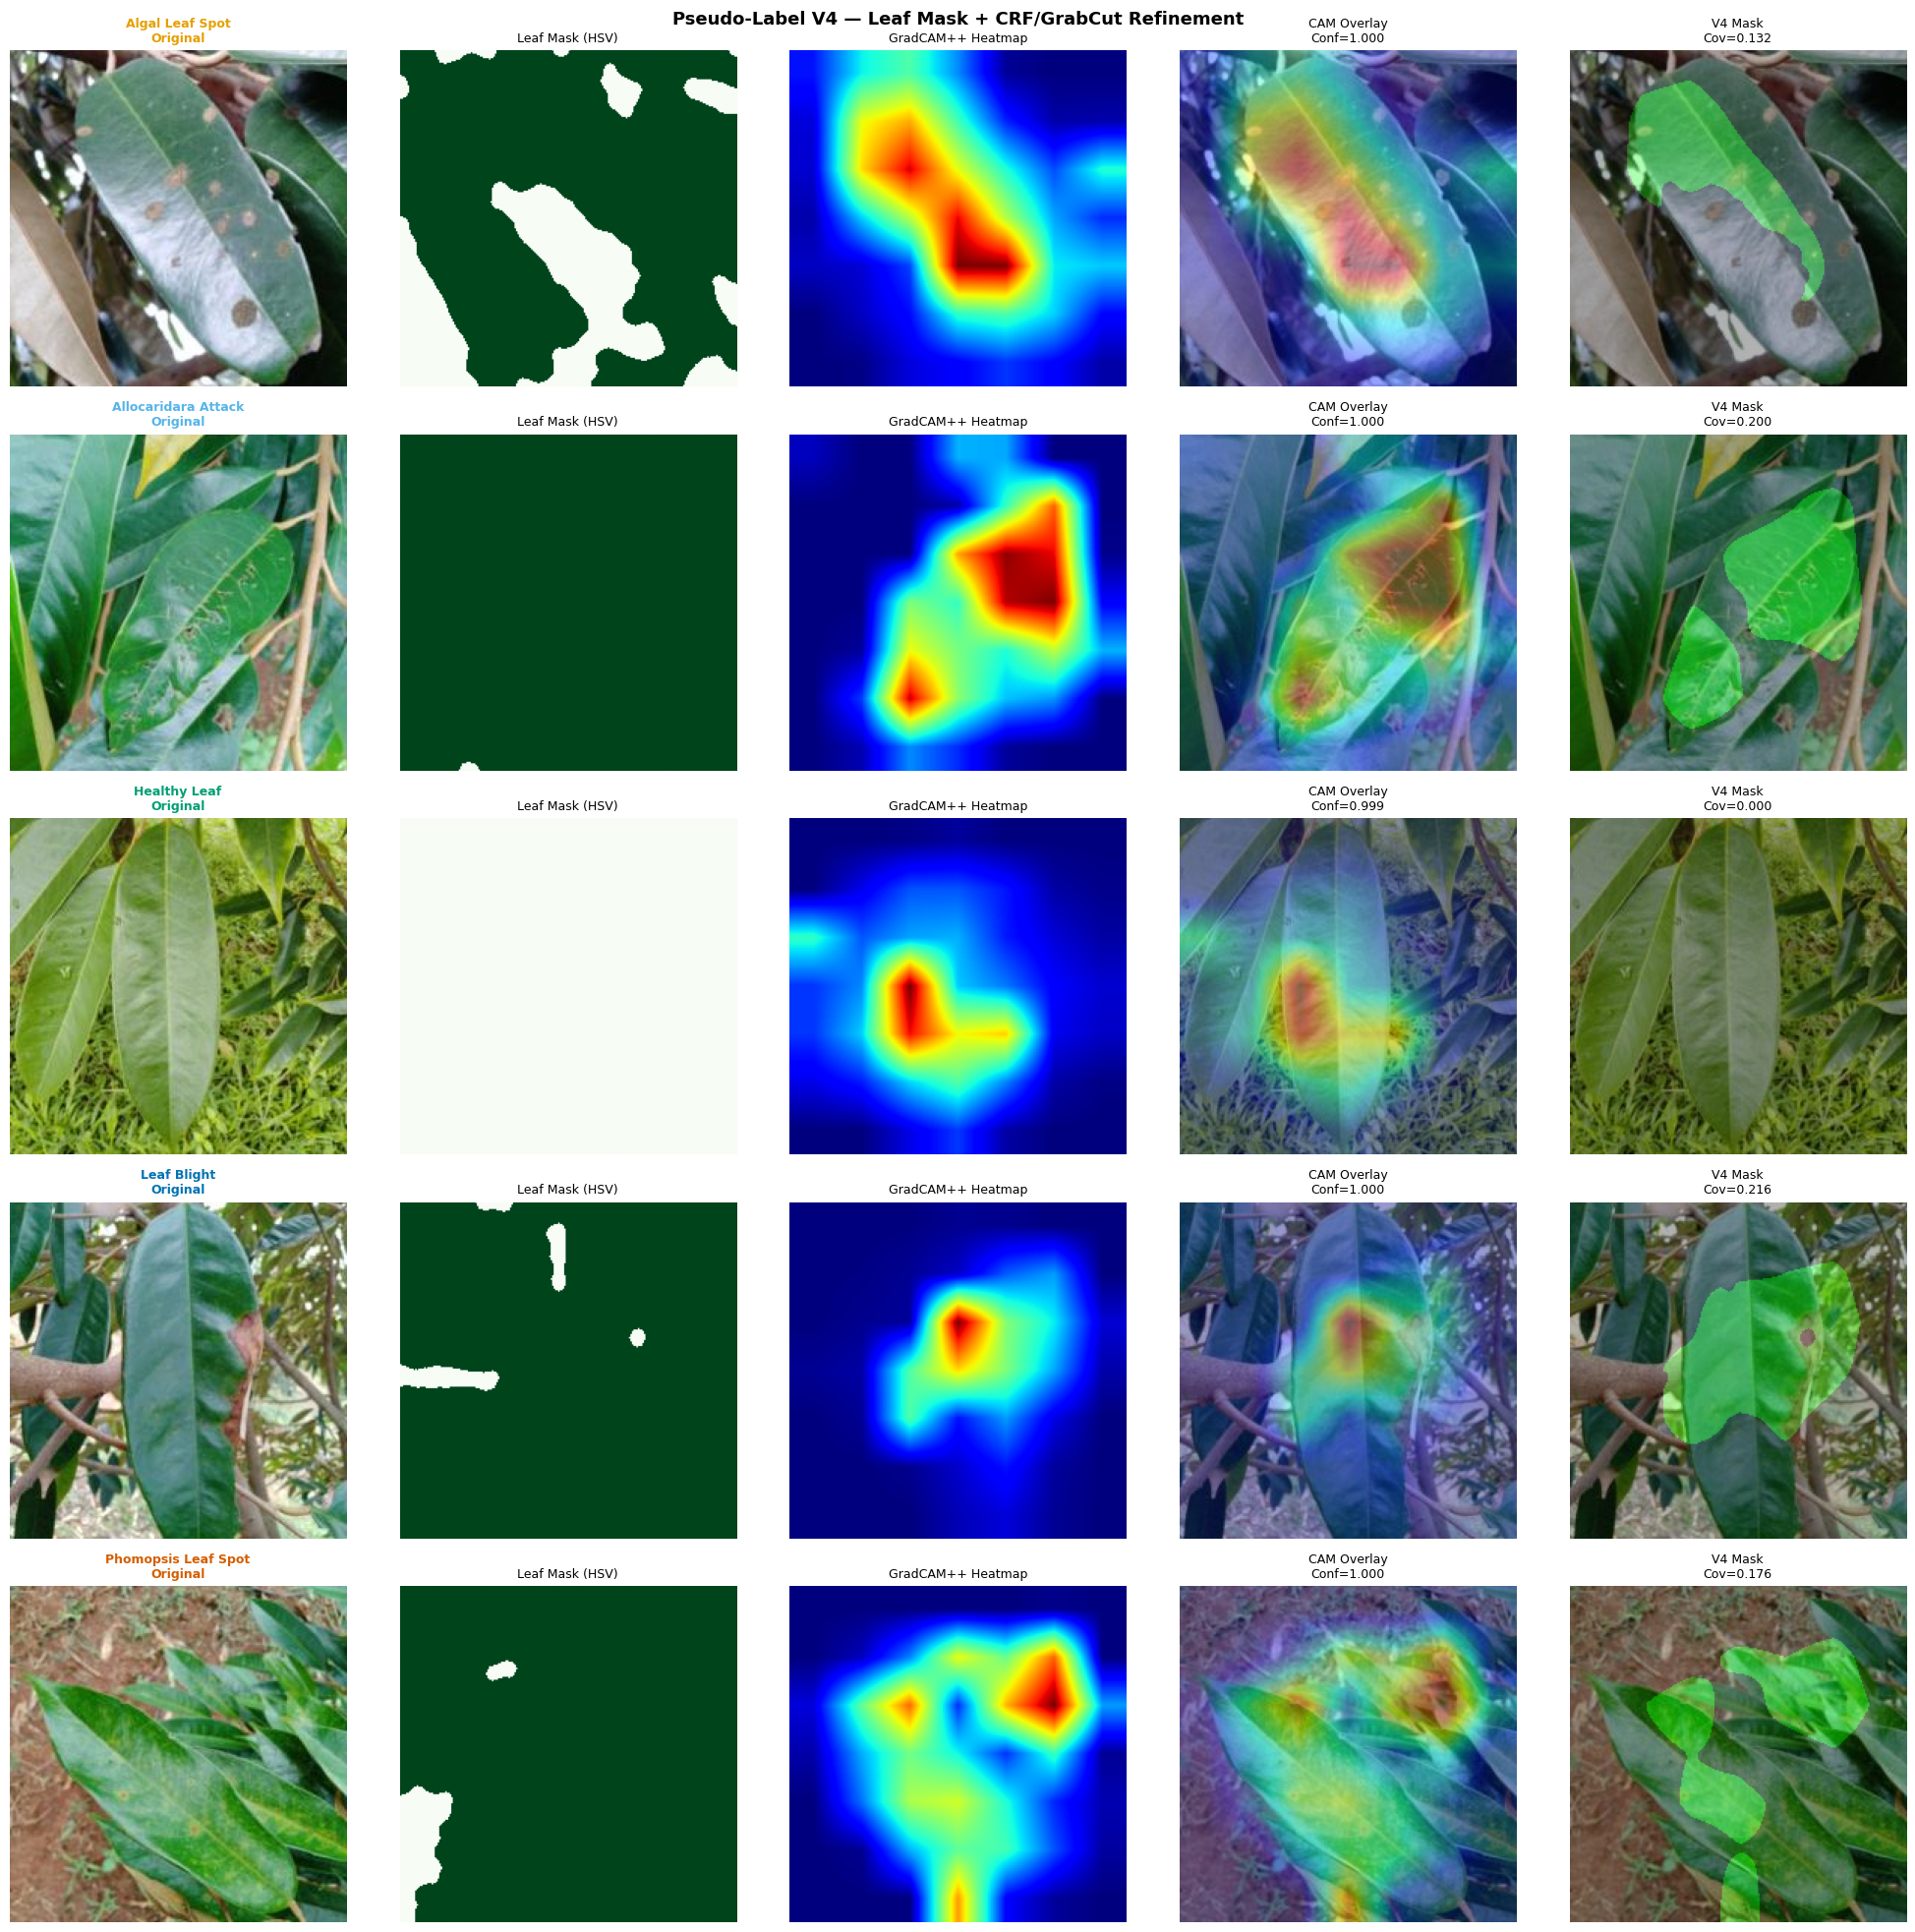

Saved → e:\Master\thesis-clean\visualizations\pseudo_labeling_v4/v4_per_class.png


In [14]:
# Side-by-side: Original | Leaf mask | V2 overlay | V4 overlay — per class
n_cls = len(CLASS_NAMES)
fig, axes = plt.subplots(n_cls, 5, figsize=(20, 4*n_cls))
fig.suptitle('Pseudo-Label V4 — Leaf Mask + CRF/GrabCut Refinement', fontsize=13, fontweight='bold')

# Load V2 viz data for comparison (re-generate for best sample per class)
v2_masks_dir = Path(proj_root) / 'notebooks' / 'data' / 'pseudo_labels_v2_train'

for i, (cls_name, cls_label, cls_color) in enumerate(zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS)):
    items = viz_by_class_v4.get(cls_name, [])
    if not items: continue
    best = max(items, key=lambda x: x['conf'])

    axes[i,0].imshow(best['orig'])
    axes[i,0].set_title(f'{cls_label}\nOriginal', fontsize=9, fontweight='bold', color=cls_color)
    axes[i,0].axis('off')

    axes[i,1].imshow(best['leaf_mask'], cmap='Greens')
    axes[i,1].set_title('Leaf Mask (HSV)', fontsize=9)
    axes[i,1].axis('off')

    axes[i,2].imshow(best['heatmap'], cmap='jet')
    axes[i,2].set_title('GradCAM++ Heatmap', fontsize=9)
    axes[i,2].axis('off')

    axes[i,3].imshow(best['overlay_cam'])
    axes[i,3].set_title(f'CAM Overlay\nConf={best["conf"]:.3f}', fontsize=9)
    axes[i,3].axis('off')

    axes[i,4].imshow(best['overlay_mask'])
    axes[i,4].set_title(f'V4 Mask\nCov={best["mask"].mean():.3f}', fontsize=9)
    axes[i,4].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_LABEL, 'v4_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR_LABEL}/v4_per_class.png')

C:\Users\pc\AppData\Local\Temp\ipykernel_19760\1133371116.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes2[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)


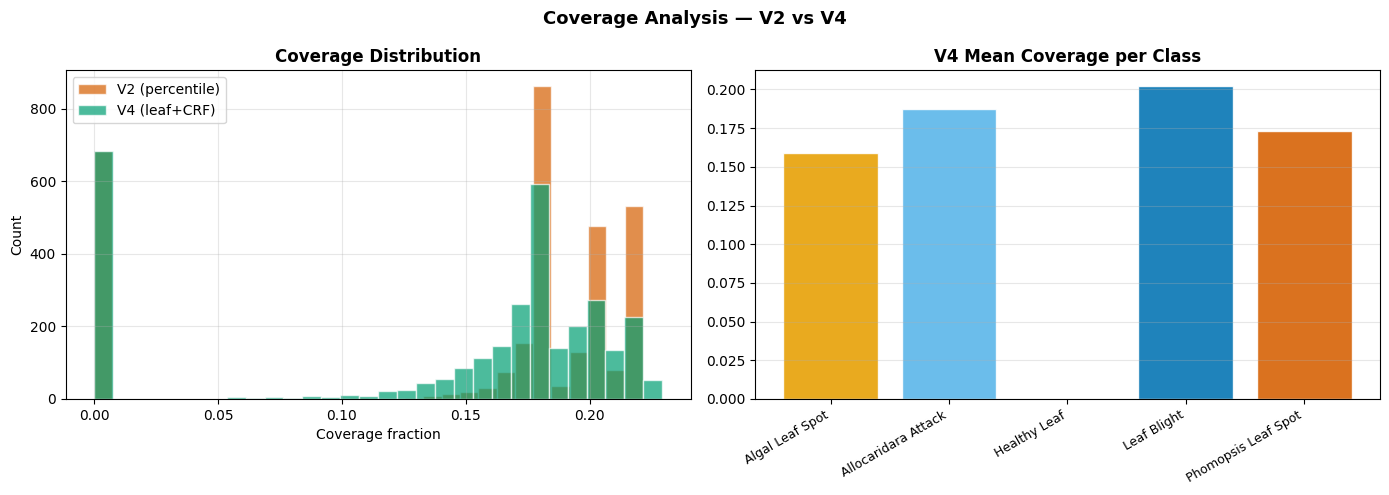

In [15]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Coverage Analysis — V2 vs V4', fontsize=13, fontweight='bold')

if df_v2 is not None:
    axes2[0].hist(df_v2['mask_coverage'], bins=30, alpha=0.7, label='V2 (percentile)', color='#D55E00', edgecolor='white')
axes2[0].hist(df_v4['mask_coverage'], bins=30, alpha=0.7, label='V4 (leaf+CRF)', color='#009E73', edgecolor='white')
axes2[0].set_title('Coverage Distribution', fontsize=12, fontweight='bold')
axes2[0].set_xlabel('Coverage fraction'); axes2[0].set_ylabel('Count')
axes2[0].legend(); axes2[0].grid(True, alpha=0.3)

per_cls = df_v4.groupby('class_name')['mask_coverage'].mean()
labels  = [IDX_TO_LABEL[CLASS_TO_IDX[n]] for n in per_cls.index]
axes2[1].bar(labels, per_cls.values, color=CLASS_COLORS, alpha=0.88, edgecolor='white')
axes2[1].set_title('V4 Mean Coverage per Class', fontsize=12, fontweight='bold')
axes2[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes2[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_LABEL, 'v4_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()

## Nhận xét — Pseudo-Label V4

*(Điền sau khi chạy xong)*

---
## PHẦN 2 — Segmentation Training V4

Cùng kiến trúc UNet++ EfficientNet-B0, FocalDice, AdamW, CosineAnnealing như V2/V3.

**Cải tiến so với V2/V3:**
- **Early stop theo `val_IoU`** thay vì `val_loss` (V2 miss best IoU epoch vì loss plateau ≠ IoU plateau)
- **patience=10** thay vì 5 (CosineAnnealing T_max=50 cần ít nhất patience=10 để không dừng sớm)
- Labels V4: background đã bị loại, boundaries theo màu sắc thực → cleaner training signal

In [16]:
IMAGE_DIR_V4 = str(processed_dir_v4)
MASK_DIR_V4  = str(pseudo_dir_v4)

TRAIN_AUG = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.ElasticTransform(p=0.2),
    A.GridDistortion(p=0.15),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

VAL_AUG = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})


class DurianSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for fname in sorted(os.listdir(mask_dir)):
            if not fname.endswith('_pseudo.png'): continue
            img_name = fname.replace('_pseudo.png', '')
            img_path = os.path.join(image_dir, img_name)
            if os.path.exists(img_path):
                self.samples.append((img_path, os.path.join(mask_dir, fname)))
        print(f'[Dataset] {len(self.samples)} pairs')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ip, mp = self.samples[idx]
        img    = np.array(Image.open(ip).convert('RGB'))
        mask   = (np.array(Image.open(mp).convert('L')) > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].unsqueeze(0).float()
        else:
            img  = torch.from_numpy(img).permute(2,0,1).float()/255
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        return {'image': img, 'label': mask, 'img_path': ip}


train_ds_aug  = DurianSegDataset(IMAGE_DIR_V4, MASK_DIR_V4, transform=TRAIN_AUG)
val_test_ds   = DurianSegDataset(IMAGE_DIR_V4, MASK_DIR_V4, transform=VAL_AUG)

n_total = len(train_ds_aug)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val
print(f'Split: train={n_train} val={n_val} test={n_test}')

rng      = np.random.default_rng(42)   # same seed as V2/V3 for fair comparison
shuffled = rng.permutation(n_total).tolist()
train_idx = shuffled[:n_train]
val_idx   = shuffled[n_train:n_train+n_val]
test_idx  = shuffled[n_train+n_val:]

train_set = Subset(train_ds_aug, train_idx)
val_set   = Subset(val_test_ds,  val_idx)
test_set  = Subset(val_test_ds,  test_idx)

train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=4, shuffle=False, num_workers=0)

b = next(iter(train_loader))
print('image:', b['image'].shape, '| mask:', b['label'].shape)

e:\Master\thesis-clean\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


[Dataset] 3104 pairs
[Dataset] 3104 pairs
Split: train=2172 val=465 test=467
image: torch.Size([4, 3, 224, 224]) | mask: torch.Size([4, 1, 224, 224])


In [17]:
seg_model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

total     = sum(p.numel() for p in seg_model.parameters())
trainable = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f'UNet++ EfficientNet-B0 | params: {total:,} | trainable: {trainable:,}')

UNet++ EfficientNet-B0 | params: 6,569,581 | trainable: 6,569,581


In [18]:
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.smooth = smooth

    def focal(self, pred, target):
        bce   = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        p_t   = torch.exp(-bce)
        return (self.alpha * (1-p_t)**self.gamma * bce).mean()

    def dice(self, pred, target):
        p     = torch.sigmoid(pred)
        inter = (p * target).sum(dim=(2,3))
        union = p.sum(dim=(2,3)) + target.sum(dim=(2,3))
        return (1 - (2*inter + self.smooth)/(union + self.smooth)).mean()

    def forward(self, pred, target): return self.focal(pred, target) + self.dice(pred, target)


EPOCHS    = 50
PATIENCE  = 10   # improved from V2's patience=5
criterion = FocalDiceLoss(alpha=0.25, gamma=2.0)
optimizer = optim.AdamW(seg_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Loss: FocalDice | Optimizer: AdamW lr=1e-4 | Scheduler: CosineAnnealing T_max={EPOCHS}')
print(f'Max epochs: {EPOCHS} | Early stop patience: {PATIENCE} (monitoring val_IoU — improvement over V2)')

Loss: FocalDice | Optimizer: AdamW lr=1e-4 | Scheduler: CosineAnnealing T_max=50
Max epochs: 50 | Early stop patience: 10 (monitoring val_IoU — improvement over V2)


In [19]:
def calc_metrics(pred_np, gt_np, smooth=1e-6):
    p  = pred_np.flatten().astype(bool)
    g  = gt_np.flatten().astype(bool)
    tp = (p & g).sum(); fp = (p & ~g).sum(); fn = (~p & g).sum()
    prec = (tp+smooth)/(tp+fp+smooth)
    rec  = (tp+smooth)/(tp+fn+smooth)
    f1   = 2*prec*rec/(prec+rec+smooth)
    dice = (2*tp+smooth)/(2*tp+fp+fn+smooth)
    iou  = (tp+smooth)/(tp+fp+fn+smooth)
    return {'iou': float(iou), 'dice': float(dice),
            'precision': float(prec), 'recall': float(rec), 'f1': float(f1)}


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_m = {'iou':[], 'dice':[], 'precision':[], 'recall':[], 'f1':[]}
    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['label'].to(device)
            out   = model(imgs)
            total_loss += criterion(out, masks).item() * imgs.size(0)
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)
            for i in range(len(preds)):
                m = calc_metrics(preds[i,0], gts[i,0])
                for k in all_m: all_m[k].append(m[k])
    return total_loss/len(loader.dataset), {k: float(np.mean(v)) for k,v in all_m.items()}


print('Metrics functions ready')

Metrics functions ready


## Training Loop — 50 epochs, early stop patience=10 (val_IoU)

**Thay đổi quan trọng so với V2**: Best checkpoint theo `val_IoU` thay vì `val_loss`.
Trong V2/V3, val_loss và val_IoU không đồng pha — early stop theo val_loss bỏ qua epoch có val_IoU cao nhất (delta 0.050 ở V3).

In [20]:
ckpt_dir   = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v4', 'checkpoints')
metric_dir = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v4', 'metrics')
os.makedirs(ckpt_dir,   exist_ok=True)
os.makedirs(metric_dir, exist_ok=True)

BEST_PATH   = os.path.join(ckpt_dir, 'unetpp_v4_best.pth')
RESUME_PATH = os.path.join(ckpt_dir, 'unetpp_v4_resume.pth')

start_epoch    = 1
best_val_iou   = 0.0   # track IoU, not loss
patience_cnt   = 0
history = {
    'train_loss':[], 'train_iou':[], 'train_dice':[],
    'val_loss':[],   'val_iou':[],   'val_dice':[],
    'val_precision':[], 'val_recall':[], 'val_f1':[], 'lr':[],
}

if os.path.exists(RESUME_PATH):
    print(f'[Resume] {RESUME_PATH}')
    ck = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    seg_model.load_state_dict(ck['model_state_dict'])
    optimizer.load_state_dict(ck['optimizer_state_dict'])
    scheduler.load_state_dict(ck['scheduler_state_dict'])
    history      = ck['history']
    best_val_iou = ck['best_val_iou']
    patience_cnt = ck['patience_cnt']
    start_epoch  = ck['epoch'] + 1
    print(f'  start_epoch={start_epoch}  best_val_iou={best_val_iou:.4f}  patience={patience_cnt}/{PATIENCE}')
else:
    print('Starting fresh training')

for epoch in range(start_epoch, EPOCHS+1):
    seg_model.train()
    t_loss = 0.0; tp=fp=fn=0

    for batch in tqdm(train_loader, desc=f'E{epoch:02d}/{EPOCHS}', leave=False):
        imgs  = batch['image'].to(device)
        masks = batch['label'].to(device)
        optimizer.zero_grad()
        out  = seg_model(imgs)
        loss = criterion(out, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seg_model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(out) > 0.5
        tp += ((preds==1)&(masks==1)).sum().item()
        fp += ((preds==1)&(masks==0)).sum().item()
        fn += ((preds==0)&(masks==1)).sum().item()

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    t_loss /= len(train_loader.dataset)
    t_iou   = tp/(tp+fp+fn+1e-7)
    t_dice  = 2*tp/(2*tp+fp+fn+1e-7)

    v_loss, v_m = evaluate(seg_model, val_loader, criterion, device)

    history['train_loss'].append(t_loss); history['train_iou'].append(t_iou)
    history['train_dice'].append(t_dice); history['val_loss'].append(v_loss)
    history['val_iou'].append(v_m['iou']); history['val_dice'].append(v_m['dice'])
    history['val_precision'].append(v_m['precision']); history['val_recall'].append(v_m['recall'])
    history['val_f1'].append(v_m['f1']); history['lr'].append(lr)

    log = (epoch % 5 == 0 or epoch <= 3 or v_m['iou'] > best_val_iou)
    if log:
        print(f'E{epoch:02d} | '
              f'train_loss={t_loss:.4f} val_loss={v_loss:.4f} | '
              f'train_iou={t_iou:.4f} val_iou={v_m["iou"]:.4f} | '
              f'val_dice={v_m["dice"]:.4f} | lr={lr:.2e}')

    # Best checkpoint by val_IoU (improved from V2 which used val_loss)
    if v_m['iou'] > best_val_iou:
        best_val_iou = v_m['iou']
        patience_cnt = 0
        torch.save({'epoch': epoch, 'model_state_dict': seg_model.state_dict(),
                    'val_iou': v_m['iou'], 'val_loss': v_loss, 'val_metrics': v_m}, BEST_PATH)
        print(f'  ✓ Best checkpoint saved (val_iou={best_val_iou:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stop at E{epoch} — val_IoU no improvement for {PATIENCE} epochs.')
            break

    torch.save({
        'epoch': epoch, 'model_state_dict': seg_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history, 'best_val_iou': best_val_iou, 'patience_cnt': patience_cnt,
    }, RESUME_PATH)

if os.path.exists(RESUME_PATH):
    os.remove(RESUME_PATH); print('Resume checkpoint removed.')

with open(os.path.join(metric_dir, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nTraining complete. {len(history["val_loss"])} epochs. Best val_IoU={best_val_iou:.4f}')

Starting fresh training


E01 | train_loss=0.7111 val_loss=0.6646 | train_iou=0.3036 val_iou=0.3599 | val_dice=0.4804 | lr=9.99e-05
  ✓ Best checkpoint saved (val_iou=0.3599)


KeyboardInterrupt: 

In [ ]:
ck = torch.load(BEST_PATH, map_location=device, weights_only=False)
seg_model.load_state_dict(ck['model_state_dict'])
seg_model.eval()
print(f'Loaded best checkpoint: epoch={ck["epoch"]}, val_iou={ck["val_iou"]:.4f}')

test_loss, test_m = evaluate(seg_model, test_loader, criterion, device)

print('\n=== Test Set Metrics (V4) ===')
print(f'  Loss      : {test_loss:.4f}')
for k, v in test_m.items():
    print(f'  {k:<10}: {v:.4f}')

with open(os.path.join(metric_dir, 'test_metrics.json'), 'w') as f:
    json.dump({'test_loss': test_loss, **test_m}, f, indent=2)
print('Test metrics saved.')

In [ ]:
BASE = os.path.join(proj_root, 'notebooks', 'models')
versions = [
    ('V1 (EfficientNet-UNet)',  os.path.join(BASE, 'segmentation',    'metrics', 'test_metrics.json')),
    ('V2 (UNet++ percentile)',  os.path.join(BASE, 'segmentation_v2', 'metrics', 'test_metrics.json')),
    ('V3 (UNet++ SAM)',         os.path.join(BASE, 'segmentation_v3', 'metrics', 'test_metrics.json')),
    ('V4 (UNet++ CRF/GrabCut)',  os.path.join(metric_dir,              'test_metrics.json')),
]

keys = ['iou', 'dice', 'precision', 'recall', 'f1']
print('=' * 82)
print(f'{"Version":<28}' + ''.join(f'{k.upper():>10}' for k in keys))
print('-' * 82)
for name, path in versions:
    if os.path.exists(path):
        with open(path) as f: m = json.load(f)
        print(f'{name:<28}' + ''.join(f'{m.get(k,0):>10.4f}' for k in keys))
    else:
        print(f'{name:<28}  [metrics not found: {path}]')
print('=' * 82)
print('NOTE: V1 evaluated on GradCAM v1 labels; V2/V3/V4 on their respective label distributions.')
print('Valid comparison: V2 vs V3 vs V4 (same architecture UNet++ EB0, same seed=42 split).')

In [ ]:
eps = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
TRAIN_C = '#0072B2'; VAL_C = '#D55E00'

for ax, tk, vk, title, ylabel in [
    (axes[0,0], 'train_loss', 'val_loss',  'Loss',   'Loss'),
    (axes[0,1], 'train_iou',  'val_iou',   'IoU',    'IoU'),
    (axes[0,2], 'train_dice', 'val_dice',  'Dice',   'Dice'),
]:
    ax.plot(eps, history[tk], color=TRAIN_C, lw=1.5, label=f'Train')
    ax.plot(eps, history[vk], color=VAL_C,   lw=1.5, label=f'Val')
    ax.set_title(f'Training vs Validation {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

axes[1,0].plot(eps, history['val_precision'], color=CLASS_COLORS[3], lw=1.5, label='Precision')
axes[1,0].plot(eps, history['val_recall'],    color=CLASS_COLORS[4], lw=1.5, label='Recall')
axes[1,0].plot(eps, history['val_f1'],        color=CLASS_COLORS[2], lw=1.5, label='F1')
axes[1,0].set_title('Val Precision / Recall / F1', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(eps, history['lr'], color=CLASS_COLORS[0], lw=1.5)
axes[1,1].set_title('LR Schedule (CosineAnnealing)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_yscale('log'); axes[1,1].grid(True, alpha=0.3)

# Bar chart: V2/V3/V4 comparison (fair — same arch)
bar_data = {}
for vname, path in versions[1:]:
    if os.path.exists(path):
        with open(path) as f: bar_data[vname] = json.load(f)

if bar_data:
    bar_keys = ['iou', 'dice', 'f1']
    x = np.arange(len(bar_keys))
    w = 0.25
    colors = CLASS_COLORS[:len(bar_data)]
    for j, (vname, m) in enumerate(bar_data.items()):
        axes[1,2].bar(x + j*w - w, [m.get(k,0) for k in bar_keys], w,
                      label=vname.split('(')[0].strip(), color=colors[j], alpha=0.85)
    axes[1,2].set_xticks(x); axes[1,2].set_xticklabels([k.upper() for k in bar_keys])
    axes[1,2].set_title('V2 vs V3 vs V4 (same arch)', fontsize=12, fontweight='bold')
    axes[1,2].set_ylim(0, 1); axes[1,2].legend(fontsize=8); axes[1,2].grid(True, alpha=0.3, axis='y')
else:
    axes[1,2].axis('off')

plt.suptitle('Segmentation V4 — UNet++ + Leaf Mask + CRF/GrabCut Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_SEG, 'training_curves_v4.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
seg_model.eval()
sample_batch = next(iter(test_loader))
imgs_t = sample_batch['image'].to(device)
gts    = sample_batch['label']

with torch.no_grad():
    out   = seg_model(imgs_t)
    probs = torch.sigmoid(out)
    preds = (probs > 0.5).float()

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
n_show = min(4, len(imgs_t))

fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))
if n_show == 1: axes = axes.reshape(1,-1)

for i in range(n_show):
    img_d = (imgs_t[i].cpu()*std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    gt_m  = gts[i,0].numpy()
    pr_m  = preds[i,0].cpu().numpy()
    pb_m  = probs[i,0].cpu().numpy()
    m     = calc_metrics(pr_m, gt_m)

    axes[i,0].imshow(img_d);               axes[i,0].set_title('Input',        fontsize=9); axes[i,0].axis('off')
    axes[i,1].imshow(gt_m,  cmap='gray');  axes[i,1].set_title('Label V4',     fontsize=9); axes[i,1].axis('off')
    axes[i,2].imshow(pb_m,  cmap='hot');   axes[i,2].set_title('Prob Map',     fontsize=9); axes[i,2].axis('off')
    axes[i,3].imshow(pr_m,  cmap='gray');  axes[i,3].set_title(f'Prediction\nIoU={m["iou"]:.3f}', fontsize=9); axes[i,3].axis('off')

plt.suptitle('V4 Test Set Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_SEG, 'test_predictions_v4.png'), dpi=150, bbox_inches='tight')
plt.show()

## Nhận xét — Segmentation V4

*(Điền sau khi chạy xong — dựa trên output thực tế)*

---
## Kết luận

*(Điền sau khi chạy xong — so sánh V2/V3/V4 và hướng tiếp theo)*